# <span style="color:#f4a6a6;"> **Exploration et nettoyage des données**</span>


In [747]:
#importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [748]:
#chargement des données
df = pd.read_csv('../data/raw/All_Pokemon.csv')

---
---
### <span style="color:#f4a6a6;"> **Exploration des données**</span>

### **1 - Exploration générale du dataset**

In [749]:
df.head() #visualisation des premières lignes du dataset

,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,...,Against Bug,Against Rock,Against Ghost,Against Dragon,Against Dark,Against Steel,Against Fairy,Height,Weight,BMI
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.7,6.9,14.1
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,13.0,13.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.0,100.0,25.0
3,3,Mega Venusaur,Grass,Poison,['Thick Fat'],80,100,123,122,120,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.4,155.5,27.0
4,4,Charmander,Fire,NaN,"['Blaze', 'Solar Power']",39,52,43,60,50,...,0.5,2.0,1.0,1.0,1.0,0.5,0.5,0.6,8.5,23.6


In [750]:
print("\nNoms des colonnes :")
print(df.columns) # Affiche les noms des colonnes du DataFrame


Noms des colonnes :
Index(['Number', 'Name', 'Type 1', 'Type 2', 'Abilities', 'HP', 'Att', 'Def',
       'Spa', 'Spd', 'Spe', 'BST', 'Mean', 'Standard Deviation', 'Generation',
       'Experience type', 'Experience to level 100', 'Final Evolution',
       'Catch Rate', 'Legendary', 'Mega Evolution', 'Alolan Form',
       'Galarian Form', 'Against Normal', 'Against Fire', 'Against Water',
       'Against Electric', 'Against Grass', 'Against Ice', 'Against Fighting',
       'Against Poison', 'Against Ground', 'Against Flying', 'Against Psychic',
       'Against Bug', 'Against Rock', 'Against Ghost', 'Against Dragon',
       'Against Dark', 'Against Steel', 'Against Fairy', 'Height', 'Weight',
       'BMI'],
      dtype='object')


#### *Signification des colonnes*

---

##### Informations générales
- **Number** : Numéro du Pokémon dans le Pokédex  
- **Name** : Nom du Pokémon  
- **Generation** : Génération (1 = Kanto, 2 = Johto, etc.)

---

#####  Types et capacités
- **Type 1** : Type principal (ex : Fire, Water)  
- **Type 2** : Type secondaire (peut être vide)  
- **Abilities** : Capacités spéciales du Pokémon  

---

#####  Statistiques de combat
- **HP** : Points de vie  
- **Att** : Attaque (physique)  
- **Def** : Défense (physique)  
- **Spa** : Attaque spéciale  
- **Spd** : Défense spéciale  
- **Spe** : Vitesse  

---

#####  Statistiques globales
- **BST (Base Stat Total)** : Somme de toutes les stats  
- **Mean** : Moyenne des stats  
- **Standard Deviation** : Variabilité des stats (équilibré ou non)

---

#####  Progression et capture
- **Experience type** : Vitesse de progression (fast, medium, slow…)  
- **Experience to level 100** : XP nécessaire pour atteindre le niveau 100  
- **Catch Rate** : Facilité à capturer le Pokémon  

---

#####  Particularités
- **Legendary** : Pokémon légendaire (True/False)  
- **Mega Evolution** : Peut méga-évoluer  
- **Final Evolution** : Dernière évolution  
- **Alolan Form** : Forme d’Alola  
- **Galarian Form** : Forme de Galar  

---

#####  Faiblesses / résistances
Toutes les colonnes **"Against ..."** indiquent les dégâts reçus contre un type donné :
 

---

#####  Caractéristiques physiques
- **Height** : Taille  
- **Weight** : Poids  
- **BMI** : Indice de masse corporelle  

In [751]:
print ("Types de données :")
df.info() #informations sur les types de données et les valeurs manquantes

Types de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number                   1032 non-null   int64  
 1   Name                     1032 non-null   object 
 2   Type 1                   1032 non-null   object 
 3   Type 2                   548 non-null    object 
 4   Abilities                1032 non-null   object 
 5   HP                       1032 non-null   int64  
 6   Att                      1032 non-null   int64  
 7   Def                      1032 non-null   int64  
 8   Spa                      1032 non-null   int64  
 9   Spd                      1032 non-null   int64  
 10  Spe                      1032 non-null   int64  
 11  BST                      1032 non-null   int64  
 12  Mean                     1032 non-null   float64
 13  Standard Deviation       1032 non-null   float64
 14  Gener

#### *Le typage des données*

##### L'analyse globale des types de données montre : 
- Une majorité de variables numériques (`int64` et `float64`)  
- Quelques variables catégorielles (`object`) 

---

##### Les types à nettoyer : 
- **Generation** : `float64` → `int64`  
- **Final Evolution** : `float64` → `bool`  
- **Legendary** : `float64` → `bool`  
- **Mega Evolution** : `float64` → `bool`  
- **Alolan Form** : `float64` → `bool`  
- **Galarian Form** : `float64` → `bool`  



In [752]:
print("\nNombre de lignes et de colonnes :")
print(df.shape) # Affiche le nombre de lignes et de colonnes du DataFrame


Nombre de lignes et de colonnes :
(1032, 44)


#### *Observations et variables*

Il y a 1032 observations et 44 variables  

In [753]:
print("\nStatistiques descriptives du dataset:")
df.describe()


Statistiques descriptives du dataset:


,Number,HP,Att,Def,Spa,Spd,Spe,BST,Mean,Standard Deviation,...,Against Bug,Against Rock,Against Ghost,Against Dragon,Against Dark,Against Steel,Against Fairy,Height,Weight,BMI
count,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,...,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000
mean,439.226744,69.906008,80.526163,74.609496,72.918605,72.139535,68.548450,438.648256,73.108043,20.028104,...,1.002180,1.239826,1.025678,0.974806,1.074855,0.992006,1.094234,1.286822,71.879845,136.735756
std,261.871350,26.189155,32.542374,30.905972,32.773495,27.625876,30.219526,120.675545,20.112591,10.830298,...,0.613111,0.699361,0.577269,0.378040,0.475292,0.511859,0.535159,1.391501,132.872741,3111.666658
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,29.166667,0.000000,...,0.250000,0.250000,0.000000,0.000000,0.250000,0.250000,0.250000,0.100000,0.100000,0.000000
25%,211.750000,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,330.000000,55.000000,12.801910,...,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,0.600000,9.000000,18.600000
50%,434.500000,67.000000,78.000000,70.000000,65.000000,70.000000,65.000000,459.000000,76.500000,18.484228,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,29.750000,28.350000
75%,667.250000,83.000000,100.000000,90.000000,95.000000,90.000000,90.000000,515.000000,85.833333,24.835709,...,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.600000,71.275000,42.200000
max,898.000000,255.000000,190.000000,230.000000,194.000000,230.000000,200.000000,780.000000,130.000000,103.215659,...,4.000000,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,20.000000,999.900000,99990.000000


### **2 - Exploration des données (manquantes, outliers, distributions)**

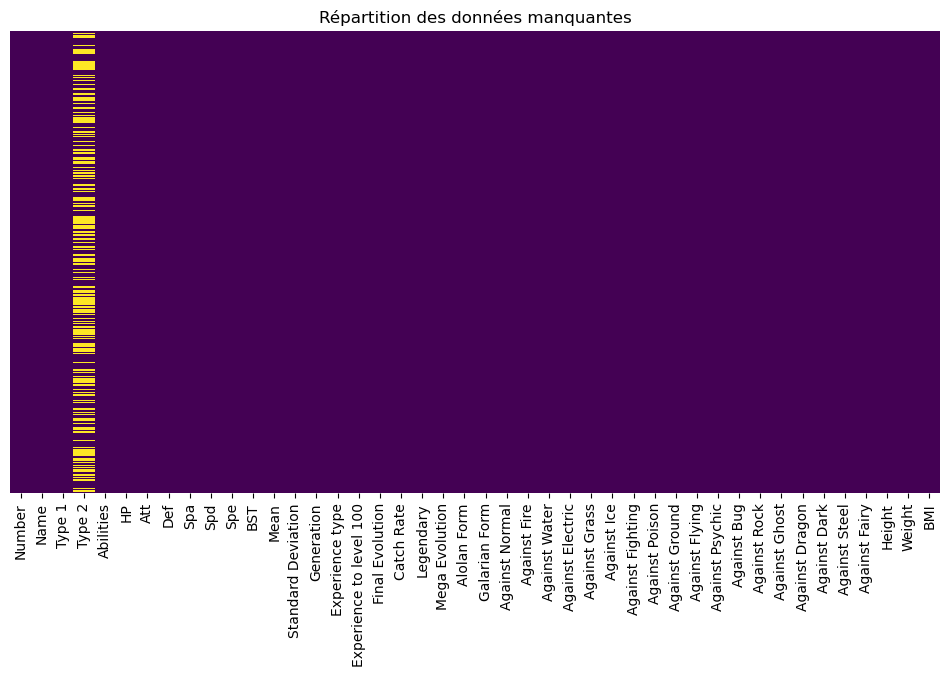

In [754]:
#variables manquantes
plt.figure(figsize=(12, 6)) # Définit une taille plus large
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Répartition des données manquantes")
plt.show()

#### *Données manquantes* 

---

La seule colonne avec des valeurs manquantes est Type 2

---

##### Nettoyage à appliquer : 

- Type 2 : Si la valeur est manquante, la remplacer par Type 1

In [755]:
#variables dupliquées
print("\nPokémons dupliqués :")
df[df["Name"].duplicated()]


Pokémons dupliqués :


,Number,Name,Type 1,Type 2,Abilities,HP,Att,Def,Spa,Spd,...,Against Bug,Against Rock,Against Ghost,Against Dragon,Against Dark,Against Steel,Against Fairy,Height,Weight,BMI


#### *Pokémons dupliquées*

Aucun.


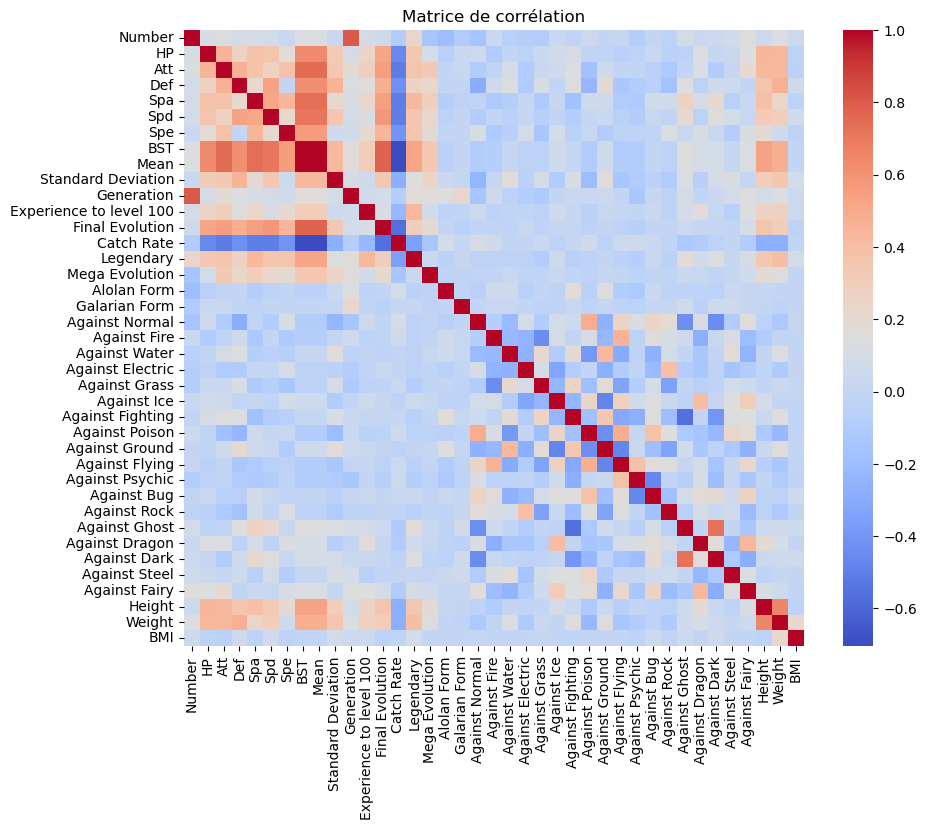

In [756]:
#matrice de correlation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

#### *Corrélation entre les variables*

---

##### Domination de BST et Mean :
- BST et Mean : forte corrélation avec toutes les statistiques individuelles (HP, Att, Def, Sp. Atk, etc.). Logique puisque le BST est la somme et Mean la moyenne de ces statistiques.



##### Lien Poids / Taille / Défense / attaque / Points de vie :
- On remarque une légère correlation entre le poids, la taille, la défense, l'attaque et les points de vie. Cela vient probablement du fait qu'un pokémon plus massif a plus de chances d'avoir une statistique de défense et attaque plus élevée.



##### Les faiblesses (Against_...) :

- On remarque que les faiblesses sont très peu corrélées aux statistiques de combat. Cela signifie que les faiblesses élémentaires d'un Pokémon ne dépendent pas de sa puissance brute.

---

##### Nettoyage à appliquer :
- Supprimer les colonnes BST et Mean.



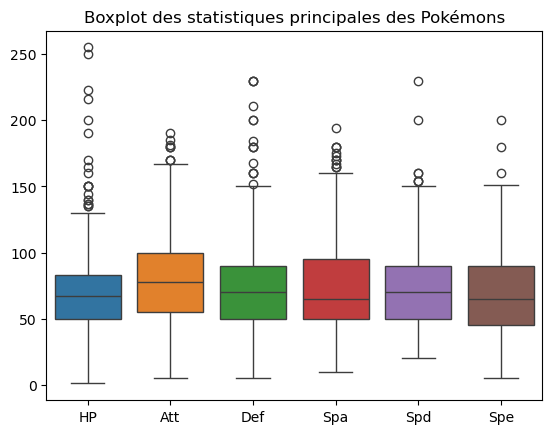

In [757]:
#visualisation des statistiques principales des Pokémons
cols = ["HP", "Att", "Def", "Spa", "Spd", "Spe"]

sns.boxplot(data=df[cols])
plt.title("Boxplot des statistiques principales des Pokémons")
plt.show()

#### *Boxplot des statistiques principales*                       

---

##### Équilibre des statistiques : 
- La plupart des statistiques ont des boîtes alignées entre 50 et 100. Cela montre que le dataset est équilibré pour la majorité des Pokémons.

##### Les "Extrêmes" (Outliers) :
- Les points isolés au-dessus des moustaches représentent l'élite des Pokémons (Pokémons Légendaires).

##### Etendue des données : 
- La hauteur totale du graphique montre que l'écart entre un Pokémon de base et un Pokémon de l'élite est immense (parfois du simple au quadruple).

---

##### Normalisation OBLIGATOIRE !

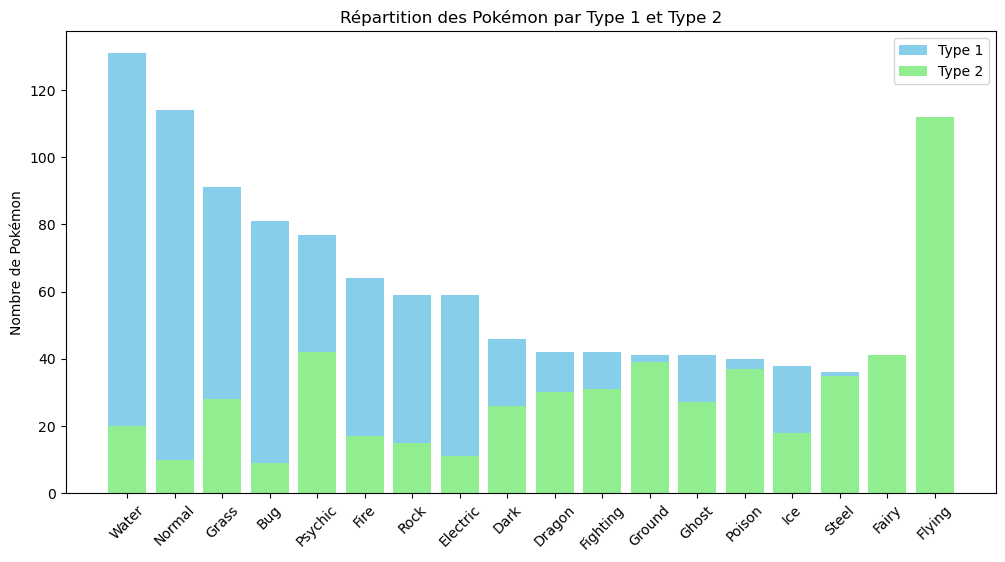

In [758]:
#répartition des types de Pokémons
plt.figure(figsize=(12,6))
plt.bar(df["Type 1"].value_counts().index, df["Type 1"].value_counts().values, color='skyblue', label="Type 1")
plt.bar(df["Type 2"].value_counts().index, df["Type 2"].value_counts().values, color='lightgreen', label="Type 2")
plt.xticks(rotation=45)
plt.ylabel("Nombre de Pokémon")
plt.title("Répartition des Pokémon par Type 1 et Type 2")
plt.legend()
plt.show()

#### *Nombre de Pokémons par type*

---

##### Répartition inégale : 
- Certains types sont très fréquents (Eau, Normal) tandis que d'autres sont beaucoup plus rares (Spectre, Fée, Glace). Cela crée un déséquilibre de classes qui peut influencer les analyses statistiques.

---

Encocage OBLIGATOIRE ! 

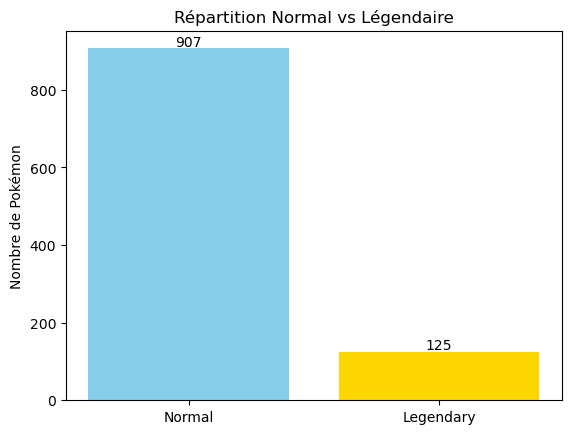


Pourcentage de Pokémons légendaires : 

12.112403100775193 %


In [759]:
#répartition des Pokémons légendaires vs normaux
counts = df['Legendary'].replace({0:'Normal', 1:'Legendary'}).value_counts()

                                         
plt.bar(counts.index, counts.values, color=['skyblue','gold'])
plt.title("Répartition Normal vs Légendaire")
plt.ylabel("Nombre de Pokémon")

for i, val in enumerate(counts.values):
    plt.text(i, val + 5, str(val), ha='center') # affichage valeurs : i=position x, val+5=position y, str(val)=texte à afficher

plt.show()

#Pourcentage de Pokémons légendaires
print ("\nPourcentage de Pokémons légendaires : \n")
nb_legend = df['Legendary'].sum()
pourcentage_legend = (nb_legend/ len(df)) * 100
print (pourcentage_legend, "%")

#### *Répartition des Pokémons Légendaires VS Normaux*

---
##### Déséquilibre des classes :
- Avec seulement 12,11 % de Pokémon légendaires contre près de 88 % de Pokémon normaux, le dataset est déséquilibré.

---
Utilisation de modèles efficaces malgré le déséquilibre des classes.

---
---
### <span style="color:#f4a6a6;">**Nettoyage**</span>

### **1 - Rappel des nettoyages à effectuer :**


##### *Les types à nettoyer :* 
- **Generation** : `float64` → `int64`  
- **Final Evolution** : `float64` → `bool`  
- **Legendary** : `float64` → `bool`  
- **Mega Evolution** : `float64` → `bool`  
- **Alolan Form** : `float64` → `bool`  
- **Galarian Form** : `float64` → `bool`  


##### *Autres nettoyages à appliquer:* 

- Type 2 : Si la valeur est manquante, la remplacer par Type 1
- Supprimer les colonnes BST et Mean.


### **2 - Nettoyage des types de données :**


In [760]:
# Conversion en variables entières
df['Generation'] = df['Generation'].astype(int)

In [761]:
# Conversion en variables booléennes
col = ["Final Evolution", "Legendary", "Mega Evolution", "Alolan Form", "Galarian Form"]
df[col] = df[col].astype(bool)

In [762]:
df.info() #vérification des types de données après conversion

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number                   1032 non-null   int64  
 1   Name                     1032 non-null   object 
 2   Type 1                   1032 non-null   object 
 3   Type 2                   548 non-null    object 
 4   Abilities                1032 non-null   object 
 5   HP                       1032 non-null   int64  
 6   Att                      1032 non-null   int64  
 7   Def                      1032 non-null   int64  
 8   Spa                      1032 non-null   int64  
 9   Spd                      1032 non-null   int64  
 10  Spe                      1032 non-null   int64  
 11  BST                      1032 non-null   int64  
 12  Mean                     1032 non-null   float64
 13  Standard Deviation       1032 non-null   float64
 14  Generation              

####    3 - Autres nettoyages : 


In [763]:
# Remplacer les valeurs manquantes de Type 2 par Type 1
df["Type 2"] = df["Type 2"].fillna(df["Type 1"])

In [764]:
# Suppression des colonnes inutiles
df = df.drop(columns=["BST", "Mean"])

---
---
### <span style="color:#f4a6a6;">**Sauvegarde du Dataset nettoyé**</span>

In [765]:
df.to_csv("../data/processed/pokemon_clean.csv", index=False)